In [1]:
from Tools_U1_plaquette import *

### This notebook reproduces the plot obtained in "Data_Fig6_SM.ipynb", comparing Heff and H_P for m=10,20,50,100 for $\lambda,g$=1, for the first 9 eigenvales

In [ ]:
g = 1.0
lam = 1.0
neig = 9
Nsize = 25

filename_Heff_varying_m = (
    f"H_P_vs_H_eff_g_{int(g)}_lam_{int(lam)}_Nsize_{int(Nsize)}_neig_{int(neig)}_"
    f"varying_m_with_expval_ns_def.npz"
)
data_varying_m = np.load(filename_Heff_varying_m)
m_list = data_varying_m['m']
E_P_all_arr = data_varying_m['E_P_all']
E_eff_all_arr = data_varying_m['E_eff_all']
err_all_arr = data_varying_m['err_all']
n12_arr = data_varying_m['n12_exp_all']
n24_arr = data_varying_m['n24_exp_all']
n13_arr = data_varying_m['n13_exp_all']
n34_arr = data_varying_m['n34_exp_all']
n1_arr = data_varying_m['n1_exp_all']
n2_arr = data_varying_m['n2_exp_all']
n3_arr = data_varying_m['n3_exp_all']
n4_arr = data_varying_m['n4_exp_all']

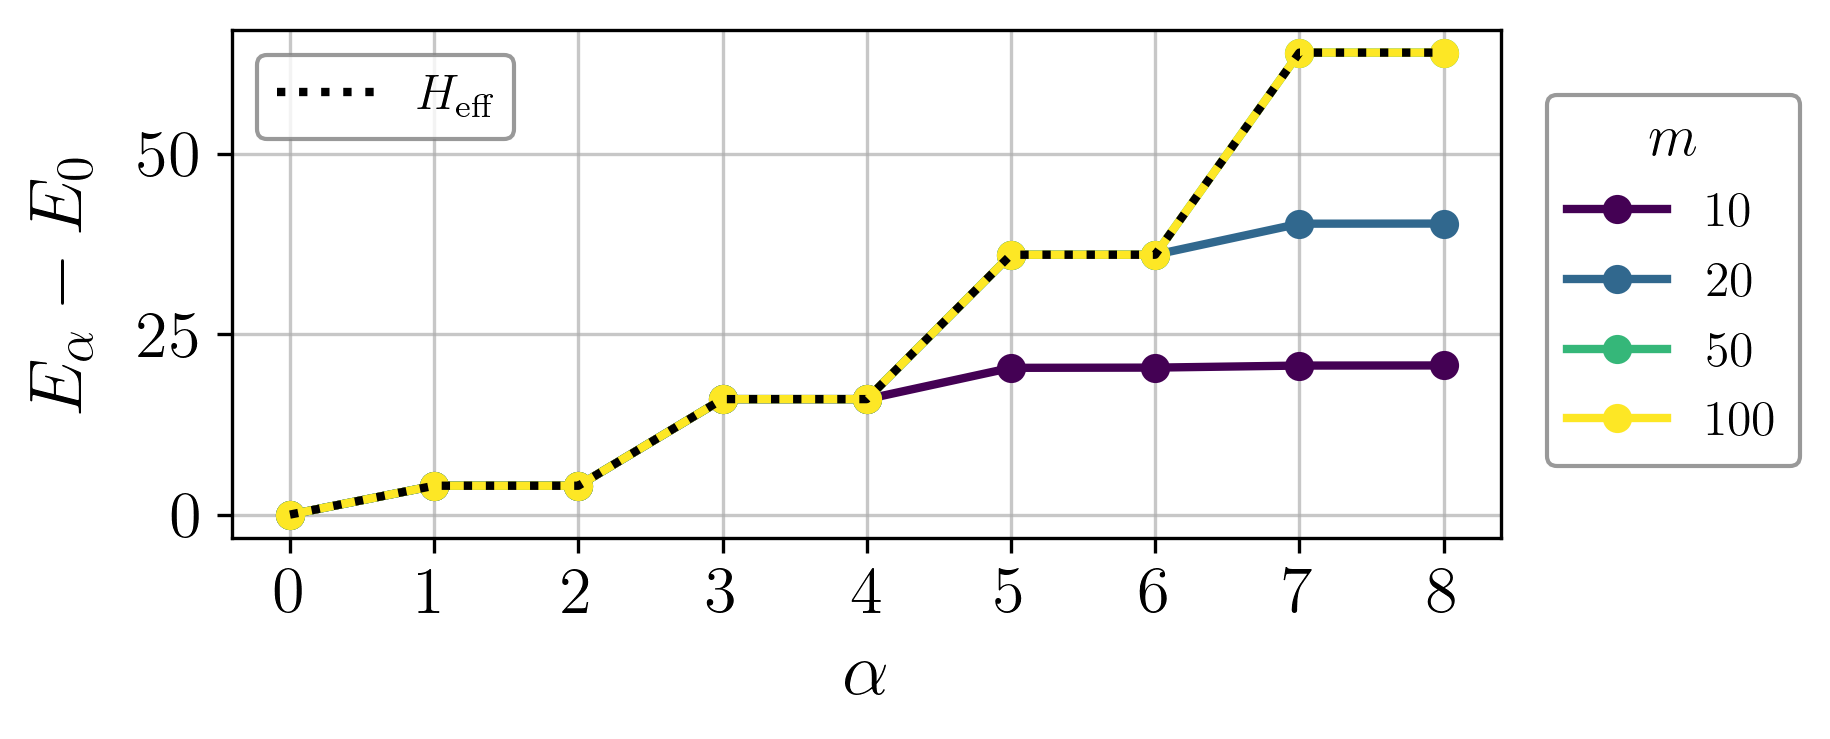

In [ ]:
plt.rcParams.update({
    #"figure.figsize": (8, 5),
    "figure.dpi": 100,
    "font.size": 22,#14,
    "font.family": "serif",
    "text.usetex": True,
    "axes.labelsize": 18,#16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlesize": 12,
    "axes.grid": False,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.fontsize": 12,#14,
    "legend.title_fontsize": 14,
    "legend.frameon": False,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots(1, 1, figsize=(6, 2.2), dpi=300)

colors_m = plt.cm.viridis(np.linspace(0, 1, len(m_list)))

lines_m = []
labels_m = []
for i, (c, m) in enumerate(zip(colors_m, m_list)):
    line, = ax.plot(
        range(neig),
        E_P_all_arr[i],
        marker='o',
        c=c
    )
    lines_m.append(line)
    labels_m.append(f"{m}")
line_eff, = ax.plot(
    E_eff_all_arr[-1],
    linestyle=":",
    color="black",
    linewidth=2,
    label=r"$H_{\rm eff}$"
)
ax.set_ylabel(r"$E_{\alpha} - E_0$", labelpad=10)
ax.set_xticks(range(neig))
ax.grid(True)
ax.set_xlabel(r"$\alpha$")
ax.legend(
    handles=[line_eff],
    loc="upper left",
    fontsize=12,
    frameon=True,
    facecolor="white",
    edgecolor="grey",
    framealpha=0.8
)
fig.legend(
    handles=lines_m,
    labels=labels_m,
    title=r"$m$",
    title_fontsize=14,
    fontsize=12,
    frameon=True,
    facecolor="white",
    edgecolor="grey",
    framealpha=0.8,
    loc="center right",
    bbox_to_anchor=(1.01, 0.5)  
)

fig.subplots_adjust(right=0.83) 
fig.savefig(
    "LGT_SCQs_plaquette_reduced_def_OCT25/"
    "H_P_vs_H_eff_combined_m_and_g_with_labels_def_def.pdf", 
    dpi=600
)
plt.show()

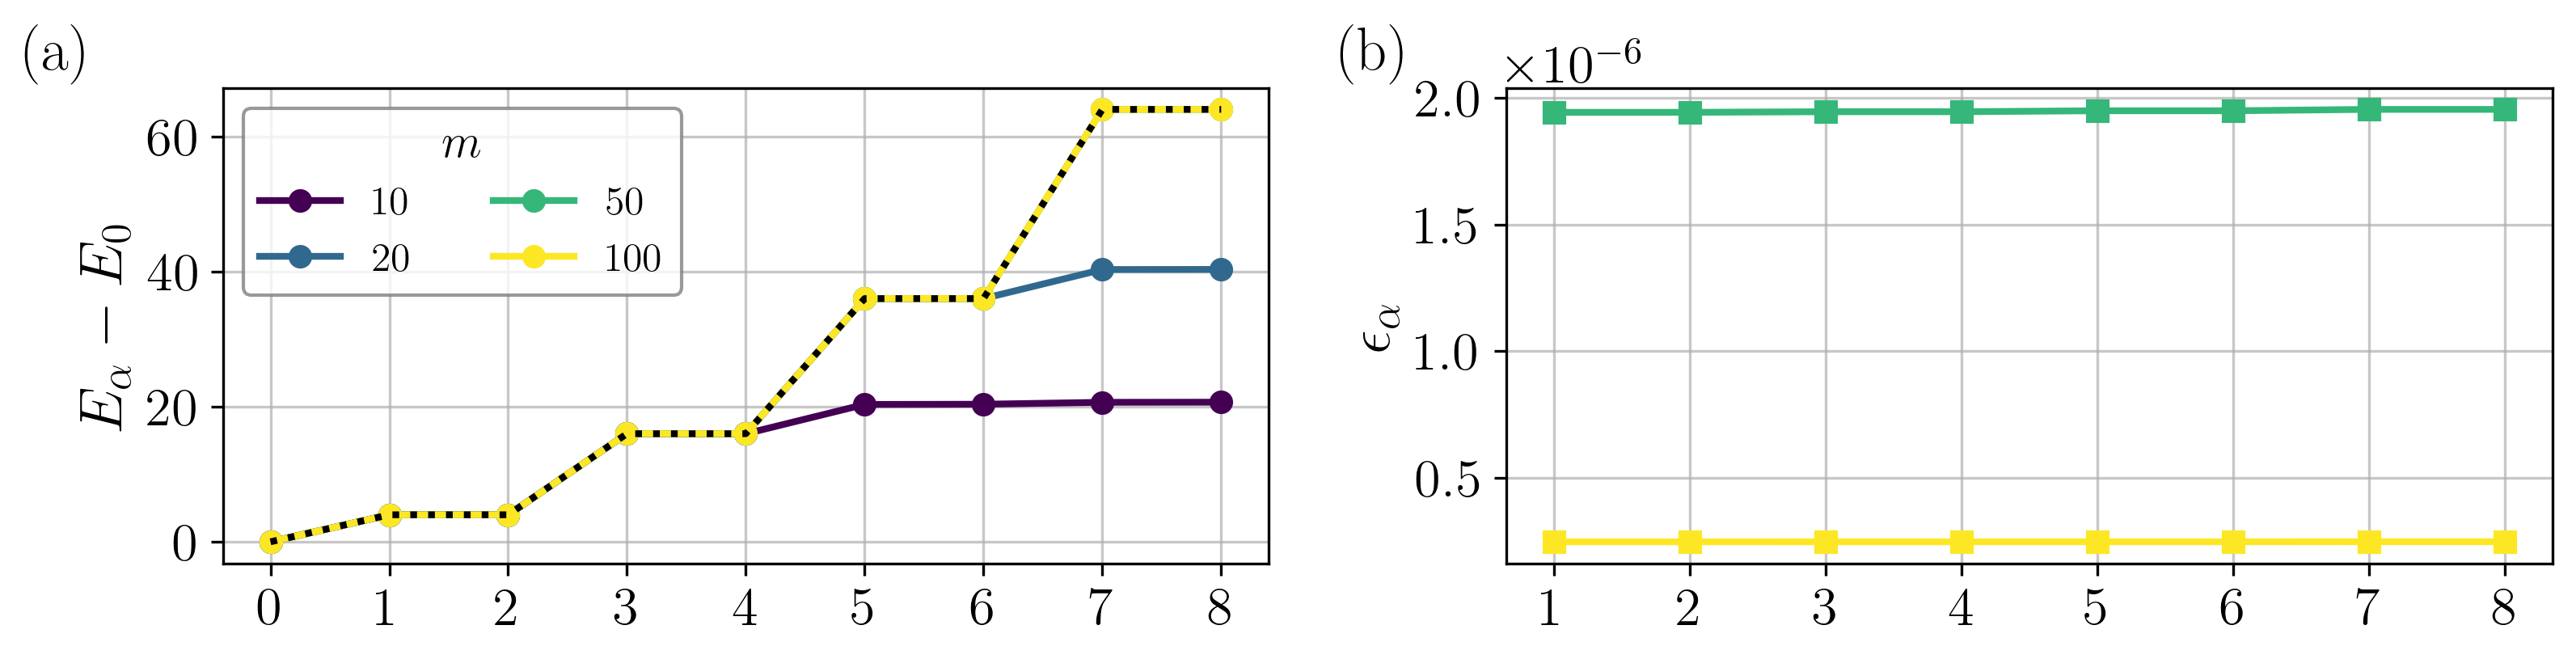

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), dpi=300)

colors_m = plt.cm.viridis(np.linspace(0, 1, len(m_list)))

# ---------------- Left plot: spectrum comparison ----------------
for i, (c, m) in enumerate(zip(colors_m, m_list)):
    axes[0].plot(
        range(neig),
        E_P_all_arr[i],
        marker='o',
        c=c,
        label=f"{m}"
    )
axes[0].plot(E_eff_all_arr[-1], linestyle = ":", c='black')
axes[0].set_ylabel(r"$E_{\alpha} - E_0$")
axes[0].set_xticks(range(neig))
axes[0].grid(True)
leg_top = axes[0].legend(
    title=r"$m$",
    title_fontsize=14,
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='grey',
    framealpha=0.8,
    ncol=2
)
leg_top.get_title().set_fontweight('bold')
axes[0].text(-0.19, 1.04, r"$(\rm a)$",
                transform=axes[0].transAxes,
                fontsize=18, fontweight='bold')

# ---------------- Right plot: relative error ----------------
axes[1].plot(
        range(1, neig),
        err_all_arr[-2][1:],
        marker='s',
        c=colors_m[-2],
)
axes[1].plot(
        range(1, neig),
        err_all_arr[-1][1:],
        marker='s',
        c=colors_m[-1],
)
axes[1].set_ylabel(r"$\epsilon_{\alpha}$")
axes[1].set_xticks(range(1, neig))
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[1].grid(True)
axes[1].text(-0.16, 1.04, r"$(\rm b)$",
                transform=axes[1].transAxes,
                fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig(    
    "LGT_SCQs_plaquette_reduced_def_OCT25/"
    "H_P_vs_H_eff_combined_m_and_g_with_labels_def.pdf", 
    dpi=600
)
plt.show()

In [5]:
for i, m in enumerate(m_list):
    print(f"\n=== m = {m:.2f} ===")
    for alpha in range(n12_arr.shape[1]):
        print(
            f"  α={alpha:2d} | "
            f"<n12>={n12_arr[i,alpha]: .3e}, "
            f"<n24>={n24_arr[i,alpha]: .3e}, "
            f"<n13>={n13_arr[i,alpha]: .3e}, "
            f"<n34>={n34_arr[i,alpha]: .3e}, "
            f"<n1>={n1_arr[i,alpha]: .3e}, "
            f"<n2>={n2_arr[i,alpha]: .3e}, "
            f"<n3>={n3_arr[i,alpha]: .3e}, "
            f"<n4>={n4_arr[i,alpha]: .3e}"
        )

E_flux = n12_arr**2 + n24_arr**2 + n13_arr**2 + n34_arr**2
#
for i, m in enumerate(m_list):
    print(f"m={m:.1f} | Σ < n^2 > (GS) = {E_flux[i,0]:.3e}")

circulation = n12_arr + n24_arr - n34_arr - n13_arr

for i, m in enumerate(m_list):
    print(f"m={m:.1f} | < curl n > (GS) = {circulation[i,0]:.3e}")


=== m = 10.00 ===
  α= 0 | <n12>=-5.568e-15, <n24>=-6.421e-16, <n13>= 2.920e-15, <n34>= 3.743e-15, <n1>=-2.648e-15, <n2>= 4.926e-15, <n3>= 8.227e-16, <n4>=-3.101e-15
  α= 1 | <n12>=-2.602e-03, <n24>=-2.602e-03, <n13>= 2.602e-03, <n34>= 2.602e-03, <n1>= 1.742e-15, <n2>= 1.432e-15, <n3>=-2.007e-15, <n4>=-1.167e-15
  α= 2 | <n12>= 2.602e-03, <n24>= 2.602e-03, <n13>=-2.602e-03, <n34>=-2.602e-03, <n1>=-7.026e-15, <n2>= 7.542e-15, <n3>= 4.349e-15, <n4>=-4.865e-15
  α= 3 | <n12>=-1.351e+00, <n24>=-1.351e+00, <n13>= 1.351e+00, <n34>= 1.351e+00, <n1>= 1.021e-14, <n2>= 1.776e-15, <n3>=-3.575e-14, <n4>= 2.376e-14
  α= 4 | <n12>= 1.351e+00, <n24>= 1.351e+00, <n13>=-1.351e+00, <n34>=-1.351e+00, <n1>=-4.663e-15, <n2>= 6.661e-15, <n3>= 4.441e-16, <n4>=-2.442e-15
  α= 5 | <n12>= 2.284e-11, <n24>= 7.747e-11, <n13>= 1.673e-11, <n34>=-3.665e-11, <n1>= 3.957e-11, <n2>= 5.463e-11, <n3>=-5.338e-11, <n4>=-4.082e-11
  α= 6 | <n12>=-2.324e-11, <n24>=-3.639e-11, <n13>= 3.632e-11, <n34>= 2.356e-11, <n1>= 1.308e